In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [12]:
df = pd.read_csv("knn_telecom.csv")

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           150 non-null    int64
 1   Gender        150 non-null    str  
 2   PlanType      150 non-null    str  
 3   Tenure        150 non-null    int64
 4   MonthlyUsage  150 non-null    int64
 5   Churn         150 non-null    int64
dtypes: int64(4), str(2)
memory usage: 7.2 KB


In [13]:
df = df.loc[:, ~df.columns.str.lower().str.contains("id")]

In [14]:
for col in df.columns:
    if df[col].dtype == "str":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [15]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

In [18]:
numeric_features = X.select_dtypes(include=["int64"]).columns

In [20]:
categorical_features = X.select_dtypes(include=["str"]).columns

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),numeric_features),
        ("cat", OneHotEncoder(drop="first"),categorical_features)
    ]
)

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state= 42)

In [24]:
k_values = range(1,16)
cv_scores = []

In [25]:
for k in k_values:
    model = Pipeline([
        ("Preprocessing", preprocessor),
        ("knn",KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(model, X, y, cv=skf, scoring = "accuracy")
    cv_scores.append(scores.mean())

In [26]:
for k , score in zip(k_values, cv_scores):
    print(f"K = {k} | CV Accuracy = {round(score,4)}")


best_k = k_values[np.argmax(cv_scores)]
print("\nBEst K Selected:", best_k)

K = 1 | CV Accuracy = 0.9533
K = 2 | CV Accuracy = 0.94
K = 3 | CV Accuracy = 0.9667
K = 4 | CV Accuracy = 0.96
K = 5 | CV Accuracy = 0.96
K = 6 | CV Accuracy = 0.96
K = 7 | CV Accuracy = 0.96
K = 8 | CV Accuracy = 0.9667
K = 9 | CV Accuracy = 0.96
K = 10 | CV Accuracy = 0.96
K = 11 | CV Accuracy = 0.96
K = 12 | CV Accuracy = 0.96
K = 13 | CV Accuracy = 0.9667
K = 14 | CV Accuracy = 0.9667
K = 15 | CV Accuracy = 0.96

BEst K Selected: 3


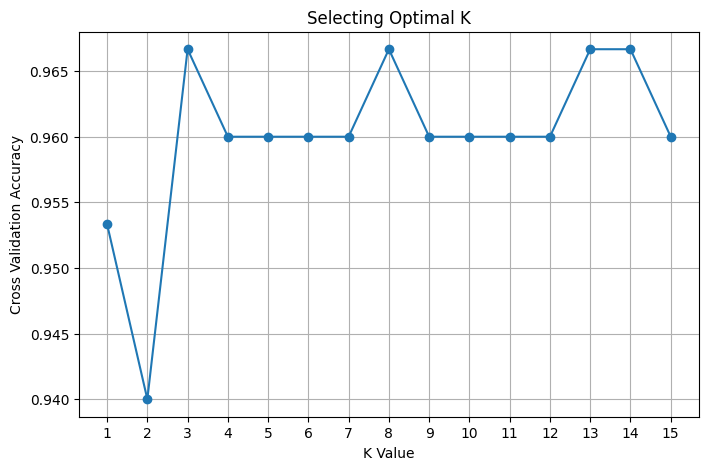

In [28]:
plt.figure(figsize=(8,5))
plt.plot(k_values ,cv_scores ,marker = 'o')
plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy")
plt.title("Selecting Optimal K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [31]:
final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X,y)

,steps,"[('preprocessing', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
user_data = {"Age":23,"Gender":"Male","PlanType": "Premium","Tenure": 12,"MonthlyUsage":350}

user_df = pd.DataFrame([user_data])

In [46]:
prediction = final_model.predict(user_df)[0]
probability = final_model.predict_proba(user_df)[0]

In [47]:
print("\nUSer Input: ")
print(user_df)


USer Input: 
   Age Gender PlanType  Tenure  MonthlyUsage
0   23   Male  Premium      12           350


In [48]:
print("\nPredicted Churn: ",prediction)
print("Prediction Probability: ",probability)


Predicted Churn:  1
Prediction Probability:  [0. 1.]
